# AI Math Mentor App: Colab Prototype

**Author:** Anchit Nayak  
**Advisor:** Dr. Qingyang Xiao

**Goal:** Build an AI-based math mentor that personlizes a problem bank, checks every submitted solution step, classifies mistakes, tracks weaknesses, recommends the next problem, and learns which feedback style is most helpful.

This notebook is designed for the **current Google Colab runtime** and uses only free open-source Python packages. It does **not** require an OpenAI API key or any paid service.

## Prototype capabilities

1. Student profile and level-based problem assignment.
2. Structured problem bank covering arithmetic, algebra, calculus, probability, and differential equations.
3. Step-by-step symbolic checking with SymPy.
4. Supervised machine-learning error classification.
5. A small deep neural network prototype for error-pattern learning.
6. Persistent attempt history and weakness analytics with SQLite.
7. Adaptive next-problem recommendation.
8. Reinforcement-learning feedback selection using an epislon-greedy contextual bandit.
9. Optional Gradio interface for a browser-based demonstration.
10. Responsbile-AI, privacy, and production-developpment guidance.

> **Important:** This is an educational prototype, not a replacement for a teacher. Production deployment should use a curated, licensed problem corpus; stronger mathematical proof checking; child-safety review; accessbility testing; and educator oversight.

## 1. Shystem architecture

```text
Student profile
       |
       v
Personalization and problem selector
       |
       v
Problem bank ---> Student submits orderred solution steps
                                  |
                                  v
                          Sybolic step checker (SymPy)
                                  |
                        +---------+----------+
                        |                    |
                        v                    v
                  Error taxonomy rules      ML/DNN error
                  classifier
                        |                    |
                        +---------+----------+
                                  |
                                  v
                          Attempt database (SQLite)
                                  |
                                  v
                        +---------+-----------+
                        |                     |
                        v                     v
                Weakness or mastery        Feedback
                model bandit
                        |                     |
                        v                     v
                        +----------+----------+
                                   |
                                   v
                      Personalized report and next problem
  ```

  The deterministic symbolic checker is the primary mathematical validator.
  Machine-learning components classify *why* a step is wrong and personalize the response; they should not be treated as the sole source of mathematical truth.
                    

In [1]:

# Install only packages that are missing from the runtime.
# Colab already includes most scientific Python libraries.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.0",
    "sympy": "sympy>=1.12",
    "sklearn": "scikit-learn>=1.4",
    "matplotlib": "matplotlib>=3.8",
    "gradio": "gradio>=4.44",
}

missing = [spec for module, spec in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Environment ready.")


Environment ready.


In [2]:

from __future__ import annotations

import json
import math
import os
import random
import re
import sqlite3
import sys
import textwrap
from collections import defaultdict
from dataclasses import asdict, dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sympy.parsing.sympy_parser import (
    convert_xor,
    implicit_multiplication_application,
    parse_expr,
    standard_transformations,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

IS_COLAB = "google.colab" in sys.modules or Path("/content").exists()
WORK_DIR = Path("/content") if IS_COLAB else Path.cwd()
DB_PATH = WORK_DIR / "ai_math_mentor.db"
EXPORT_DIR = WORK_DIR / "ai_math_mentor_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Keep this False when running all cells automatically.
RUN_GRADIO = False

print(f"Python: {sys.version.split()[0]}")
print(f"Working directory: {WORK_DIR}")
print(f"Database path: {DB_PATH}")


Python: 3.13.15
Working directory: /content
Database path: /content/ai_math_mentor.db


## 2. Core data models and starter problem bank

A production problem bank should be sourced from maerials that are licensed for reuse and reviewed by qualified educators. The starter bank below is intentionally small and self-contained so that the prototype can run immediately.

In [3]:

@dataclass
class StudentProfile:
    student_id: str
    display_name: str
    grade_band: str
    current_levels: Dict[str, str]
    preferred_feedback: str = "socratic"
    accessibility_notes: str = ""


@dataclass
class ExpectedStep:
    math: str
    concept: str
    explanation: str


@dataclass
class MathProblem:
    problem_id: str
    topic: str
    subtopic: str
    grade_band: str
    difficulty: int
    prompt: str
    expected_steps: List[ExpectedStep]
    final_answer: str
    skills: List[str]
    hints: List[str]


PROBLEM_BANK: List[MathProblem] = [
    MathProblem(
        problem_id="ARITH-001",
        topic="Arithmetic",
        subtopic="Fractions",
        grade_band="Grades 5-7",
        difficulty=1,
        prompt="Compute 3/4 + 2/3. Show a common-denominator step and simplify.",
        expected_steps=[
            ExpectedStep("3/4 + 2/3", "identify_operation", "Identify the two fractions to add."),
            ExpectedStep("9/12 + 8/12", "common_denominator", "Rewrite both fractions with denominator 12."),
            ExpectedStep("17/12", "add_numerators", "Add the numerators while keeping the denominator."),
            ExpectedStep("1 + 5/12", "mixed_number", "Convert the improper fraction to a mixed number."),
        ],
        final_answer="17/12",
        skills=["fraction addition", "least common denominator", "simplification"],
        hints=["The least common denominator of 4 and 3 is 12.", "Multiply 3/4 by 3/3 and 2/3 by 4/4."],
    ),
    MathProblem(
        problem_id="ALG-LIN-001",
        topic="Algebra",
        subtopic="Linear equations",
        grade_band="Grades 7-10",
        difficulty=1,
        prompt="Solve 2x + 3 = 11. Show each algebraic transformation.",
        expected_steps=[
            ExpectedStep("2*x + 3 = 11", "equation_setup", "Restate the equation."),
            ExpectedStep("2*x = 8", "inverse_operation", "Subtract 3 from both sides."),
            ExpectedStep("x = 4", "isolate_variable", "Divide both sides by 2."),
        ],
        final_answer="x = 4",
        skills=["inverse operations", "equation balance", "variable isolation"],
        hints=["Undo the +3 first.", "Apply the same operation to both sides."],
    ),
    MathProblem(
        problem_id="ALG-QUAD-001",
        topic="Algebra",
        subtopic="Quadratic equations",
        grade_band="Grades 9-12",
        difficulty=2,
        prompt="Solve x^2 - 5x + 6 = 0 by factoring.",
        expected_steps=[
            ExpectedStep("x**2 - 5*x + 6 = 0", "equation_setup", "Restate the quadratic equation."),
            ExpectedStep("(x - 2)*(x - 3) = 0", "factoring", "Factor the quadratic."),
            ExpectedStep("x = 2", "zero_product_property", "Set the first factor equal to zero."),
            ExpectedStep("x = 3", "zero_product_property", "Set the second factor equal to zero."),
        ],
        final_answer="x = 2 or x = 3",
        skills=["factoring", "zero-product property", "quadratic roots"],
        hints=["Find two numbers whose product is 6 and sum is -5.", "Use the zero-product property after factoring."],
    ),
    MathProblem(
        problem_id="CALC-DERIV-001",
        topic="Calculus",
        subtopic="Polynomial derivatives",
        grade_band="College / AP",
        difficulty=2,
        prompt="Differentiate f(x) = x^3 - 4x + 7 with respect to x.",
        expected_steps=[
            ExpectedStep("Derivative(x**3 - 4*x + 7, x)", "derivative_setup", "Write the derivative operator."),
            ExpectedStep("3*x**2 - 4 + 0", "power_rule", "Apply the power rule and constant rule term by term."),
            ExpectedStep("3*x**2 - 4", "simplification", "Simplify the derivative."),
        ],
        final_answer="3*x**2 - 4",
        skills=["power rule", "constant rule", "symbolic simplification"],
        hints=["d/dx(x^n) = n*x^(n-1).", "The derivative of a constant is zero."],
    ),
    MathProblem(
        problem_id="PROB-001",
        topic="Probability",
        subtopic="Complement rule",
        grade_band="Grades 9-12 / College",
        difficulty=2,
        prompt="Two fair coins are tossed. Find the probability of at least one head using the complement rule.",
        expected_steps=[
            ExpectedStep("P_none = (1/2)**2", "independence", "Compute the probability of no heads."),
            ExpectedStep("P_at_least_one = 1 - P_none", "complement_rule", "Use the complement rule."),
            ExpectedStep("P_at_least_one = 3/4", "simplification", "Simplify the probability."),
        ],
        final_answer="3/4",
        skills=["independent events", "complement rule", "probability simplification"],
        hints=["The complement of at least one head is zero heads.", "P(TT) = 1/2 times 1/2."],
    ),
    MathProblem(
        problem_id="DE-EXP-001",
        topic="Differential Equations",
        subtopic="First-order separable equations",
        grade_band="College",
        difficulty=3,
        prompt="Solve dy/dt = 3y with y(0) = 2. Show separation, integration, and the initial-condition step.",
        expected_steps=[
            ExpectedStep("1/y", "separation", "Separate variables conceptually: dy/y = 3 dt."),
            ExpectedStep("log(y) = 3*t + C", "integration", "Integrate both sides."),
            ExpectedStep("y = C*exp(3*t)", "exponentiation", "Exponentiate and absorb constants."),
            ExpectedStep("y = 2*exp(3*t)", "initial_condition", "Use y(0) = 2."),
        ],
        final_answer="y = 2*exp(3*t)",
        skills=["separation of variables", "integration", "initial conditions", "exponential solutions"],
        hints=["Move y to the left before integrating.", "After exponentiating, use the initial condition to find C."],
    ),
]

problem_df = pd.DataFrame([
    {
        "problem_id": p.problem_id,
        "topic": p.topic,
        "subtopic": p.subtopic,
        "grade_band": p.grade_band,
        "difficulty": p.difficulty,
        "prompt": p.prompt,
        "skills": ", ".join(p.skills),
    }
    for p in PROBLEM_BANK
])
problem_df


,problem_id,topic,subtopic,grade_band,difficulty,prompt,skills
0,ARITH-001,Arithmetic,Fractions,Grades 5-7,1,Compute 3/4 + 2/3. Show a common-denominator s...,"fraction addition, least common denominator, s..."
1,ALG-LIN-001,Algebra,Linear equations,Grades 7-10,1,Solve 2x + 3 = 11. Show each algebraic transfo...,"inverse operations, equation balance, variable..."
2,ALG-QUAD-001,Algebra,Quadratic equations,Grades 9-12,2,Solve x^2 - 5x + 6 = 0 by factoring.,"factoring, zero-product property, quadratic roots"
3,CALC-DERIV-001,Calculus,Polynomial derivatives,College / AP,2,Differentiate f(x) = x^3 - 4x + 7 with respect...,"power rule, constant rule, symbolic simplifica..."
4,PROB-001,Probability,Complement rule,Grades 9-12 / College,2,Two fair coins are tossed. Find the probabilit...,"independent events, complement rule, probabili..."
5,DE-EXP-001,Differential Equations,First-order separable equations,College,3,Solve dy/dt = 3y with y(0) = 2. Show separatio...,"separation of variables, integration, initial ..."


In [4]:

PROBLEMS_BY_ID = {p.problem_id: p for p in PROBLEM_BANK}

LEVEL_TO_DIFFICULTY = {
    "entry": 1,
    "beginner": 1,
    "intermediate": 2,
    "advanced": 3,
}


def normalize_level(level: str) -> str:
    level = (level or "entry").strip().lower()
    for known in LEVEL_TO_DIFFICULTY:
        if known in level:
            return known
    return "entry"


def assign_initial_problems(profile: StudentProfile, limit: int = 5) -> List[MathProblem]:
    """Select starter problems that are close to the student's stated levels."""
    scored: List[Tuple[float, MathProblem]] = []
    for problem in PROBLEM_BANK:
        stated = profile.current_levels.get(problem.topic, "entry")
        target_difficulty = LEVEL_TO_DIFFICULTY[normalize_level(stated)]
        score = 3.0 - abs(problem.difficulty - target_difficulty)
        if profile.grade_band.lower() in problem.grade_band.lower():
            score += 0.5
        scored.append((score, problem))
    scored.sort(key=lambda item: (-item[0], item[1].difficulty, item[1].problem_id))
    return [p for _, p in scored[:limit]]


sample_profile = StudentProfile(
    student_id="student_demo_001",
    display_name="Demo Student",
    grade_band="Grades 9-12",
    current_levels={
        "Algebra": "intermediate",
        "Calculus": "entry",
        "Probability": "intermediate",
        "Differential Equations": "entry",
    },
    preferred_feedback="socratic",
)

pd.DataFrame([
    {"problem_id": p.problem_id, "topic": p.topic, "difficulty": p.difficulty, "prompt": p.prompt}
    for p in assign_initial_problems(sample_profile)
])


,problem_id,topic,difficulty,prompt
0,ALG-QUAD-001,Algebra,2,Solve x^2 - 5x + 6 = 0 by factoring.
1,PROB-001,Probability,2,Two fair coins are tossed. Find the probabilit...
2,ARITH-001,Arithmetic,1,Compute 3/4 + 2/3. Show a common-denominator s...
3,ALG-LIN-001,Algebra,1,Solve 2x + 3 = 11. Show each algebraic transfo...
4,CALC-DERIV-001,Calculus,2,Differentiate f(x) = x^3 - 4x + 7 with respect...



## 3. Symbolic parser and step-equivalence engine

The checker converts each line into a SymPy expression or equation. It then compares the student's step with the expected trajectory. For equations, it compares solution sets when possible and otherwise compares normalized equation forms.

Supported examples include:

- `2x + 3 = 11`
- `2*x = 8`

Natural-language proofs, geometry diagrams, and advanced theorem provving require additional modules beyond this prototype.

In [5]:

TRANSFORMATIONS = standard_transformations + (
    implicit_multiplication_application,
    convert_xor,
)

LOCAL_DICT = {
    "x": sp.Symbol("x"),
    "y": sp.Symbol("y", positive=True),
    "t": sp.Symbol("t"),
    "C": sp.Symbol("C"),
    "P_none": sp.Symbol("P_none"),
    "P_at_least_one": sp.Symbol("P_at_least_one"),
    "Derivative": sp.Derivative,
    "diff": sp.diff,
    "exp": sp.exp,
    "log": sp.log,
    "ln": sp.log,
    "sqrt": sp.sqrt,
    "sin": sp.sin,
    "cos": sp.cos,
    "tan": sp.tan,
}


def clean_math_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"^step\s*\d+\s*[:.)-]?\s*", "", text, flags=re.I)
    replacements = {
        "−": "-",
        "–": "-",
        "×": "*",
        "÷": "/",
        "π": "pi",
        "√": "sqrt",
        "^": "**",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = text.replace("d/dx", "Derivative")
    return text.strip()


def parse_statement(text: str) -> sp.Basic:
    cleaned = clean_math_text(text)
    if not cleaned:
        raise ValueError("Empty step")
    if cleaned.count("=") == 1:
        lhs_text, rhs_text = [part.strip() for part in cleaned.split("=", 1)]
        lhs = parse_expr(lhs_text, local_dict=LOCAL_DICT, transformations=TRANSFORMATIONS, evaluate=True)
        rhs = parse_expr(rhs_text, local_dict=LOCAL_DICT, transformations=TRANSFORMATIONS, evaluate=True)
        return sp.Eq(lhs, rhs, evaluate=False)
    return parse_expr(cleaned, local_dict=LOCAL_DICT, transformations=TRANSFORMATIONS, evaluate=True)


def equation_residual(statement: sp.Basic) -> sp.Basic:
    if isinstance(statement, sp.Equality):
        return sp.expand(statement.lhs - statement.rhs)
    return sp.expand(statement)


def _safe_solution_set(statement: sp.Basic, variable: sp.Symbol) -> Optional[sp.Set]:
    try:
        residual = equation_residual(statement)
        return sp.solveset(residual, variable, domain=sp.S.Complexes)
    except Exception:
        return None


def symbolic_equivalent(a: sp.Basic, b: sp.Basic) -> bool:
    """Return True when two expressions/equations are mathematically equivalent."""
    if isinstance(a, sp.Equality) and isinstance(b, sp.Equality):
        symbols = sorted(a.free_symbols | b.free_symbols, key=lambda s: s.name)
        if len(symbols) == 1:
            set_a = _safe_solution_set(a, symbols[0])
            set_b = _safe_solution_set(b, symbols[0])
            if set_a is not None and set_b is not None and set_a == set_b:
                return True

        ra = sp.factor(equation_residual(a))
        rb = sp.factor(equation_residual(b))
        try:
            if sp.simplify(ra - rb) == 0 or sp.simplify(ra + rb) == 0:
                return True
            if rb != 0:
                ratio = sp.simplify(ra / rb)
                if not ratio.free_symbols and ratio != 0:
                    return True
        except Exception:
            pass
        return False

    if isinstance(a, sp.Equality) != isinstance(b, sp.Equality):
        return False

    try:
        return bool(sp.simplify(a - b) == 0)
    except Exception:
        return False


def numeric_probe(statement: sp.Basic, substitutions: Optional[Dict[sp.Symbol, float]] = None) -> Optional[float]:
    """Evaluate a residual/expression numerically for diagnostic purposes."""
    substitutions = substitutions or {sp.Symbol("x"): 2.0, sp.Symbol("t"): 1.0, sp.Symbol("y"): 2.0}
    try:
        value = equation_residual(statement).subs(substitutions)
        return float(sp.N(value))
    except Exception:
        return None


# Quick parser checks
for example in ["2x + 3 = 11", "x = 4", "3/4 + 2/3", "3*x**2 - 4"]:
    print(example, "->", parse_statement(example))


2x + 3 = 11 -> Eq(2*x + 3, 11)
x = 4 -> Eq(x, 4)
3/4 + 2/3 -> 17/12
3*x**2 - 4 -> 3*x**2 - 4


## 4. Error taxonomy and supervised machine learning

The model predicts one of these labels:

- `correct`
- `calculation_error`
- `sign_error`
- `algebra_transformation_error`

For the demonstration, a synthetic labeled corpus is generated from educator-style templates. Replace it in production with de-identified, consented, educator-reviewed examples.

In [6]:

ERROR_LABELS = [
    "correct",
    "calculation_error",
    "sign_error",
    "algebra_transformation_error",
    "concept_gap",
    "incomplete_step",
    "format_or_parse_error",
]


def build_synthetic_error_dataset(seed: int = SEED) -> pd.DataFrame:
    rng = random.Random(seed)
    templates = {
        "correct": [
            "student step {step}; expected {expected}; equivalent symbolic result; correct operation",
            "valid transformation from {previous} to {step}; equation remains balanced",
            "correct use of {concept}; result {step}",
        ],
        "calculation_error": [
            "student computed {step} but expected {expected}; arithmetic value is wrong",
            "incorrect addition multiplication or fraction simplification in {step}",
            "number calculation mismatch between {step} and {expected}",
        ],
        "sign_error": [
            "student used the wrong sign in {step}; expected {expected}",
            "negative sign was lost or reversed after {previous}",
            "plus minus error in {step}",
        ],
        "algebra_transformation_error": [
            "operation was not applied to both sides in {step}; expected {expected}",
            "invalid distribution factoring cancellation or variable isolation in {step}",
            "equation balance changed from {previous} to {step}",
        ],
        "concept_gap": [
            "student selected the wrong rule for {concept}; step {step}",
            "missing understanding of {concept}; expected approach {expected}",
            "used an unrelated formula in {step}",
        ],
        "incomplete_step": [
            "step {step} is unfinished and does not reach {expected}",
            "student skipped necessary reasoning after {previous}",
            "partial expression without a complete transformation: {step}",
        ],
        "format_or_parse_error": [
            "cannot parse student notation {step}; use explicit equals signs and operators",
            "ambiguous or malformed math input in {step}",
            "unrecognized notation prevents symbolic evaluation: {step}",
        ],
    }
    concepts = [
        "fraction addition", "inverse operations", "factoring", "power rule",
        "complement rule", "separation of variables", "initial condition",
    ]
    steps = [
        "2*x=8", "x=4", "9/12+8/12", "17/12", "3*x**2-4",
        "P=3/4", "y=2*exp(3*t)", "(x-2)*(x-3)=0",
    ]
    wrong_steps = [
        "2*x=14", "x=-4", "9/12+8/12=17/24", "3*x**2+4",
        "P=1/4", "y=2+exp(3*t)", "x**2-6=0", "2*x+3=8",
    ]
    rows = []
    for label, label_templates in templates.items():
        for i in range(36):
            correct_step = rng.choice(steps)
            step = correct_step if label == "correct" else rng.choice(wrong_steps)
            expected = rng.choice(steps)
            previous = rng.choice(steps)
            concept = rng.choice(concepts)
            text = rng.choice(label_templates).format(
                step=step,
                expected=expected,
                previous=previous,
                concept=concept,
            )
            if i % 3 == 0:
                text += f"; topic {rng.choice(['algebra', 'calculus', 'probability', 'fractions', 'differential equations'])}"
            rows.append({"text": text, "label": label})
    rng.shuffle(rows)
    return pd.DataFrame(rows)


error_dataset = build_synthetic_error_dataset()
print(error_dataset.shape)
error_dataset.head()


(252, 2)


,text,label
0,negative sign was lost or reversed after P=3/4,sign_error
1,number calculation mismatch between P=1/4 and ...,calculation_error
2,student skipped necessary reasoning after 2*x=8,incomplete_step
3,ambiguous or malformed math input in x=-4,format_or_parse_error
4,incorrect addition multiplication or fraction ...,calculation_error


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    error_dataset["text"],
    error_dataset["label"],
    test_size=0.25,
    random_state=SEED,
    stratify=error_dataset["label"],
)

ERROR_CLASSIFIER = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            analyzer="word",
            min_df=1,
            max_features=2000,
        ),
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

ERROR_CLASSIFIER.fit(X_train, y_train)
pred = ERROR_CLASSIFIER.predict(X_test)
print(f"Supervised ML accuracy on the synthetic holdout set: {accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred, zero_division=0))


Supervised ML accuracy on the synthetic holdout set: 1.000
                              precision    recall  f1-score   support

algebra_transformation_error       1.00      1.00      1.00         9
           calculation_error       1.00      1.00      1.00         9
                 concept_gap       1.00      1.00      1.00         9
                     correct       1.00      1.00      1.00         9
       format_or_parse_error       1.00      1.00      1.00         9
             incomplete_step       1.00      1.00      1.00         9
                  sign_error       1.00      1.00      1.00         9

                    accuracy                           1.00        63
                   macro avg       1.00      1.00      1.00        63
                weighted avg       1.00      1.00      1.00        63



## 5. Deep neural network prototype

This compact multiplayer perceptron has two hidden layers. It is intentionally small enough for free Colab CPU execution. In a mature product, a transformer or math-aware encoder could be fine-tuned on a much larger educator-refciewed dataset, while the symbolic checker remains the final mathematical authority.

In [8]:

DNN_VECTORIZER = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    sublinear_tf=True,
)
X_train_dnn = DNN_VECTORIZER.fit_transform(X_train).toarray()
X_test_dnn = DNN_VECTORIZER.transform(X_test).toarray()

DNN_LABEL_ENCODER = LabelEncoder()
y_train_dnn = DNN_LABEL_ENCODER.fit_transform(y_train)
y_test_dnn = DNN_LABEL_ENCODER.transform(y_test)

DNN_CLASSIFIER = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=350,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=SEED,
)
DNN_CLASSIFIER.fit(X_train_dnn, y_train_dnn)
dnn_pred = DNN_CLASSIFIER.predict(X_test_dnn)
print(f"DNN prototype accuracy on the synthetic holdout set: {accuracy_score(y_test_dnn, dnn_pred):.3f}")


DNN prototype accuracy on the synthetic holdout set: 1.000


## 6.Rule-assisted step diagnosis

A hybrid design is safer than repying on an ML classifier alone:

1. Parse the step.
2. Compare it sybolically with the expected step.
3. Apply transparent diagnostic rules.
4. Use ML/DNN only when the rules do not provide a confident cateory.

In [9]:

@dataclass
class StepEvaluation:
    student_step_index: int
    student_step: str
    matched_expected_index: Optional[int]
    expected_step: Optional[str]
    is_correct: bool
    error_type: str
    confidence: float
    concept: str
    explanation: str
    skipped_expected_steps: List[str] = field(default_factory=list)
    parse_error: Optional[str] = None


def extract_numbers(text: str) -> List[float]:
    values = []
    for token in re.findall(r"[-+]?\d+(?:\.\d+)?(?:/\d+(?:\.\d+)?)?", text):
        try:
            if "/" in token:
                num, den = token.split("/", 1)
                values.append(float(num) / float(den))
            else:
                values.append(float(token))
        except Exception:
            pass
    return values


def has_sign_pattern_difference(student: str, expected: str) -> bool:
    s = clean_math_text(student).replace(" ", "")
    e = clean_math_text(expected).replace(" ", "")
    s_ops = re.findall(r"[+-]", s)
    e_ops = re.findall(r"[+-]", e)
    return s_ops != e_ops and len(s_ops) == len(e_ops)


def build_classifier_text(
    student_step: str,
    expected_step: str,
    previous_step: str,
    concept: str,
    diagnostic: str,
) -> str:
    return (
        f"student step {student_step}; expected {expected_step}; previous {previous_step}; "
        f"concept {concept}; diagnostic {diagnostic}"
    )


def ml_error_prediction(text: str) -> Tuple[str, float]:
    probabilities = ERROR_CLASSIFIER.predict_proba([text])[0]
    labels = ERROR_CLASSIFIER.classes_
    idx = int(np.argmax(probabilities))
    return str(labels[idx]), float(probabilities[idx])


def dnn_error_prediction(text: str) -> Tuple[str, float]:
    vector = DNN_VECTORIZER.transform([text]).toarray()
    probabilities = DNN_CLASSIFIER.predict_proba(vector)[0]
    idx = int(np.argmax(probabilities))
    label = DNN_LABEL_ENCODER.inverse_transform([idx])[0]
    return str(label), float(probabilities[idx])


def classify_incorrect_step(
    student_step: str,
    expected_step: str,
    previous_step: str,
    concept: str,
    parse_exception: Optional[Exception] = None,
) -> Tuple[str, float, str]:
    if parse_exception is not None:
        return (
            "format_or_parse_error",
            0.99,
            "The notation could not be parsed. Use one mathematical statement per line and explicit operators when needed.",
        )

    stripped = clean_math_text(student_step)
    if len(stripped) <= 2 or stripped.endswith(("=", "+", "-", "*", "/")):
        return (
            "incomplete_step",
            0.95,
            "The line appears incomplete. Finish the mathematical statement before moving to the next step.",
        )

    if has_sign_pattern_difference(student_step, expected_step):
        return (
            "sign_error",
            0.88,
            "A plus or minus sign differs from the expected transformation. Recheck signs before simplifying.",
        )

    student_numbers = extract_numbers(student_step)
    expected_numbers = extract_numbers(expected_step)
    if student_numbers and expected_numbers and set(student_numbers) != set(expected_numbers):
        # If the structure is otherwise similar, this is likely arithmetic.
        student_letters = re.sub(r"[-+]?\d+(?:\.\d+)?(?:/\d+(?:\.\d+)?)?", "N", clean_math_text(student_step))
        expected_letters = re.sub(r"[-+]?\d+(?:\.\d+)?(?:/\d+(?:\.\d+)?)?", "N", clean_math_text(expected_step))
        if student_letters.replace(" ", "") == expected_letters.replace(" ", ""):
            return (
                "calculation_error",
                0.90,
                "The operation pattern is plausible, but one or more numerical calculations do not match.",
            )

    diagnostic_text = build_classifier_text(
        student_step, expected_step, previous_step, concept, "symbolically not equivalent"
    )
    ml_label, ml_conf = ml_error_prediction(diagnostic_text)
    dnn_label, dnn_conf = dnn_error_prediction(diagnostic_text)

    if ml_label == dnn_label:
        return ml_label, min(0.95, 0.55 + 0.45 * max(ml_conf, dnn_conf)), (
            f"Both learned classifiers identified this as {ml_label.replace('_', ' ')}. "
            "Review the expected concept and compare each transformation."
        )

    # Conservative fallback when learned models disagree.
    if concept in {"power_rule", "complement_rule", "separation", "integration", "initial_condition", "factoring"}:
        return (
            "concept_gap",
            0.62,
            f"The step does not match the expected use of {concept.replace('_', ' ')}. Review that concept before retrying.",
        )

    return (
        "algebra_transformation_error",
        0.60,
        "The transformation is not symbolically equivalent to the expected step. Check whether the same legal operation was applied throughout.",
    )


In [10]:

def evaluate_solution_steps(problem: MathProblem, student_steps: Sequence[str]) -> List[StepEvaluation]:
    """Align submitted steps to the expected trajectory and diagnose each line."""
    expected_parsed: List[Optional[sp.Basic]] = []
    for expected in problem.expected_steps:
        try:
            expected_parsed.append(parse_statement(expected.math))
        except Exception:
            expected_parsed.append(None)

    results: List[StepEvaluation] = []
    next_expected_index = 0
    previous_student_step = "start of solution"

    for student_index, raw_step in enumerate(student_steps, start=1):
        raw_step = str(raw_step).strip()
        if not raw_step:
            continue

        try:
            parsed_student = parse_statement(raw_step)
            parse_exception = None
        except Exception as exc:
            parsed_student = None
            parse_exception = exc

        matched_index = None
        if parsed_student is not None:
            for j in range(next_expected_index, len(problem.expected_steps)):
                expected_obj = expected_parsed[j]
                if expected_obj is not None and symbolic_equivalent(parsed_student, expected_obj):
                    matched_index = j
                    break

        if matched_index is not None:
            skipped = [s.math for s in problem.expected_steps[next_expected_index:matched_index]]
            expected = problem.expected_steps[matched_index]
            explanation = "This step is mathematically equivalent to the expected step."
            if skipped:
                explanation += " It is correct, but some explanatory steps were skipped."
            result = StepEvaluation(
                student_step_index=student_index,
                student_step=raw_step,
                matched_expected_index=matched_index,
                expected_step=expected.math,
                is_correct=True,
                error_type="correct",
                confidence=0.99,
                concept=expected.concept,
                explanation=explanation,
                skipped_expected_steps=skipped,
            )
            next_expected_index = matched_index + 1
        else:
            target_index = min(next_expected_index, len(problem.expected_steps) - 1)
            expected = problem.expected_steps[target_index]
            label, confidence, explanation = classify_incorrect_step(
                student_step=raw_step,
                expected_step=expected.math,
                previous_step=previous_student_step,
                concept=expected.concept,
                parse_exception=parse_exception,
            )
            result = StepEvaluation(
                student_step_index=student_index,
                student_step=raw_step,
                matched_expected_index=None,
                expected_step=expected.math,
                is_correct=False,
                error_type=label,
                confidence=confidence,
                concept=expected.concept,
                explanation=explanation,
                parse_error=str(parse_exception) if parse_exception else None,
            )

        results.append(result)
        previous_student_step = raw_step

    return results


def solution_score(evaluations: Sequence[StepEvaluation], problem: MathProblem) -> Dict[str, float]:
    if not evaluations:
        return {"step_accuracy": 0.0, "coverage": 0.0, "overall_score": 0.0}
    correct_count = sum(item.is_correct for item in evaluations)
    unique_matches = len({item.matched_expected_index for item in evaluations if item.matched_expected_index is not None})
    step_accuracy = correct_count / len(evaluations)
    coverage = unique_matches / max(1, len(problem.expected_steps))
    overall = 100.0 * (0.65 * step_accuracy + 0.35 * coverage)
    return {
        "step_accuracy": round(step_accuracy, 3),
        "coverage": round(coverage, 3),
        "overall_score": round(overall, 1),
    }


def evaluations_to_frame(evaluations: Sequence[StepEvaluation]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "student_step": e.student_step_index,
            "submitted": e.student_step,
            "correct": e.is_correct,
            "error_type": e.error_type,
            "confidence": round(e.confidence, 3),
            "concept": e.concept,
            "expected": e.expected_step,
            "explanation": e.explanation,
        }
        for e in evaluations
    ])


# Demonstration containing one arithmetic/algebra mistake.
demo_problem = PROBLEMS_BY_ID["ALG-LIN-001"]
demo_steps = [
    "2x + 3 = 11",
    "2x = 14",  # incorrect subtraction
    "x = 7",
]
demo_evaluations = evaluate_solution_steps(demo_problem, demo_steps)
print(solution_score(demo_evaluations, demo_problem))
evaluations_to_frame(demo_evaluations)


{'step_accuracy': 0.333, 'coverage': 0.333, 'overall_score': 33.3}


,student_step,submitted,correct,error_type,confidence,concept,expected,explanation
0,1,2x + 3 = 11,True,correct,0.99,equation_setup,2*x + 3 = 11,This step is mathematically equivalent to the ...
1,2,2x = 14,False,algebra_transformation_error,0.60,inverse_operation,2*x = 8,The transformation is not symbolically equival...
2,3,x = 7,False,algebra_transformation_error,0.60,inverse_operation,2*x = 8,The transformation is not symbolically equival...


## 7. Persistent student-attempt database

SQLite is used for a lightweight prototype. A production system would normally use a managed relational database with encryption, role-based access, audit logs, parental/guardian consent controls where applicable, retention limits, and strict separation of identity data from learning analytics.

In [12]:

def get_connection(db_path: Path = DB_PATH) -> sqlite3.Connection:
    connection = sqlite3.connect(str(db_path))
    connection.row_factory = sqlite3.Row
    return connection


def initialize_database(db_path: Path = DB_PATH) -> None:
    with get_connection(db_path) as conn:
        conn.executescript(
            """
            CREATE TABLE IF NOT EXISTS students (
                student_id TEXT PRIMARY KEY,
                display_name TEXT NOT NULL,
                grade_band TEXT NOT NULL,
                current_levels_json TEXT NOT NULL,
                preferred_feedback TEXT NOT NULL,
                accessibility_notes TEXT,
                created_at TEXT NOT NULL
            );

            CREATE TABLE IF NOT EXISTS attempts (
                attempt_id INTEGER PRIMARY KEY AUTOINCREMENT,
                student_id TEXT NOT NULL,
                problem_id TEXT NOT NULL,
                topic TEXT NOT NULL,
                difficulty INTEGER NOT NULL,
                overall_score REAL NOT NULL,
                submitted_at TEXT NOT NULL,
                FOREIGN KEY(student_id) REFERENCES students(student_id)
            );

            CREATE TABLE IF NOT EXISTS step_evaluations (
                step_evaluation_id INTEGER PRIMARY KEY AUTOINCREMENT,
                attempt_id INTEGER NOT NULL,
                student_step_index INTEGER NOT NULL,
                submitted_step TEXT NOT NULL,
                expected_step TEXT,
                is_correct INTEGER NOT NULL,
                error_type TEXT NOT NULL,
                confidence REAL NOT NULL,
                concept TEXT NOT NULL,
                explanation TEXT NOT NULL,
                FOREIGN KEY(attempt_id) REFERENCES attempts(attempt_id)
            );

            CREATE TABLE IF NOT EXISTS feedback_events (
                feedback_event_id INTEGER PRIMARY KEY AUTOINCREMENT,
                student_id TEXT NOT NULL,
                context_key TEXT NOT NULL,
                feedback_style TEXT NOT NULL,
                reward REAL NOT NULL,
                created_at TEXT NOT NULL
            );
            """
        )


def upsert_student(profile: StudentProfile, db_path: Path = DB_PATH) -> None:
    now = datetime.now(timezone.utc).isoformat()
    with get_connection(db_path) as conn:
        conn.execute(
            """
            INSERT INTO students (
                student_id, display_name, grade_band, current_levels_json,
                preferred_feedback, accessibility_notes, created_at
            ) VALUES (?, ?, ?, ?, ?, ?, ?)
            ON CONFLICT(student_id) DO UPDATE SET
                display_name=excluded.display_name,
                grade_band=excluded.grade_band,
                current_levels_json=excluded.current_levels_json,
                preferred_feedback=excluded.preferred_feedback,
                accessibility_notes=excluded.accessibility_notes
            """,
            (
                profile.student_id,
                profile.display_name,
                profile.grade_band,
                json.dumps(profile.current_levels),
                profile.preferred_feedback,
                profile.accessibility_notes,
                now,
            ),
        )


def record_attempt(
    profile: StudentProfile,
    problem: MathProblem,
    evaluations: Sequence[StepEvaluation],
    db_path: Path = DB_PATH,
) -> int:
    upsert_student(profile, db_path)
    score = solution_score(evaluations, problem)["overall_score"]
    now = datetime.now(timezone.utc).isoformat()
    with get_connection(db_path) as conn:
        cursor = conn.execute(
            """
            INSERT INTO attempts (student_id, problem_id, topic, difficulty, overall_score, submitted_at)
            VALUES (?, ?, ?, ?, ?, ?)
            """,
            (profile.student_id, problem.problem_id, problem.topic, problem.difficulty, score, now),
        )
        attempt_id = int(cursor.lastrowid)
        conn.executemany(
            """
            INSERT INTO step_evaluations (
                attempt_id, student_step_index, submitted_step, expected_step,
                is_correct, error_type, confidence, concept, explanation
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
            """,
            [
                (
                    attempt_id,
                    e.student_step_index,
                    e.student_step,
                    e.expected_step,
                    int(e.is_correct),
                    e.error_type,
                    e.confidence,
                    e.concept,
                    e.explanation,
                )
                for e in evaluations
            ],
        )
    return attempt_id


initialize_database()
demo_attempt_id = record_attempt(sample_profile, demo_problem, demo_evaluations)
print("Saved demonstration attempt:", demo_attempt_id)


Saved demonstration attempt: 2


## 8. Weakness profile, mastery estimate, and adaptive recommendation

The mastery score below is a transparent heuristic rather than a psychometrically validated model. A production system could replace it with Bayesian Knowledge Tracing, Deep Knowledge Tracing, Item Response Theory, or a calibrated hybrid.

In [13]:

def load_student_history(student_id: str, db_path: Path = DB_PATH) -> pd.DataFrame:
    query = """
        SELECT
            a.attempt_id,
            a.problem_id,
            a.topic,
            a.difficulty,
            a.overall_score,
            a.submitted_at,
            s.student_step_index,
            s.is_correct,
            s.error_type,
            s.confidence,
            s.concept
        FROM attempts a
        JOIN step_evaluations s ON a.attempt_id = s.attempt_id
        WHERE a.student_id = ?
        ORDER BY a.submitted_at, s.student_step_index
    """
    with get_connection(db_path) as conn:
        return pd.read_sql_query(query, conn, params=(student_id,))


def weakness_summary(student_id: str, db_path: Path = DB_PATH) -> pd.DataFrame:
    history = load_student_history(student_id, db_path)
    if history.empty:
        return pd.DataFrame(columns=["topic", "concept", "attempted_steps", "correct_steps", "error_rate", "mastery"])

    grouped = (
        history.groupby(["topic", "concept"], as_index=False)
        .agg(
            attempted_steps=("is_correct", "size"),
            correct_steps=("is_correct", "sum"),
            avg_difficulty=("difficulty", "mean"),
        )
    )
    grouped["error_rate"] = 1.0 - grouped["correct_steps"] / grouped["attempted_steps"]
    # Smoothed mastery: correct evidence plus a small prior, then difficulty adjustment.
    grouped["mastery"] = (
        (grouped["correct_steps"] + 1.0) / (grouped["attempted_steps"] + 2.0)
    ) * (1.0 + 0.05 * (grouped["avg_difficulty"] - 1.0))
    grouped["mastery"] = grouped["mastery"].clip(0.0, 1.0)
    return grouped.sort_values(["mastery", "attempted_steps"], ascending=[True, False]).reset_index(drop=True)


def recommend_next_problem(
    profile: StudentProfile,
    student_id: Optional[str] = None,
    attempted_problem_ids: Optional[Iterable[str]] = None,
    db_path: Path = DB_PATH,
) -> Tuple[MathProblem, pd.DataFrame]:
    student_id = student_id or profile.student_id
    attempted_problem_ids = set(attempted_problem_ids or [])
    weaknesses = weakness_summary(student_id, db_path)

    weak_topics = defaultdict(float)
    weak_concepts = defaultdict(float)
    for _, row in weaknesses.iterrows():
        weak_topics[row["topic"]] = max(weak_topics[row["topic"]], float(row["error_rate"]))
        weak_concepts[row["concept"]] = max(weak_concepts[row["concept"]], float(row["error_rate"]))

    scored = []
    for problem in PROBLEM_BANK:
        stated_level = normalize_level(profile.current_levels.get(problem.topic, "entry"))
        target = LEVEL_TO_DIFFICULTY[stated_level]
        score = 2.0 - abs(problem.difficulty - target)
        score += 2.5 * weak_topics.get(problem.topic, 0.0)
        score += sum(0.8 * weak_concepts.get(step.concept, 0.0) for step in problem.expected_steps)
        if problem.problem_id not in attempted_problem_ids:
            score += 0.4
        scored.append((score, problem))

    scored.sort(key=lambda item: (-item[0], item[1].difficulty, item[1].problem_id))
    recommendation_table = pd.DataFrame([
        {
            "rank": rank,
            "problem_id": problem.problem_id,
            "topic": problem.topic,
            "difficulty": problem.difficulty,
            "score": round(score, 3),
            "prompt": problem.prompt,
        }
        for rank, (score, problem) in enumerate(scored, start=1)
    ])
    return scored[0][1], recommendation_table


weaknesses = weakness_summary(sample_profile.student_id)
weaknesses


,topic,concept,attempted_steps,correct_steps,avg_difficulty,error_rate,mastery
0,Algebra,inverse_operation,4,0,1.0,1.0,0.166667
1,Algebra,equation_setup,2,2,1.0,0.0,0.750000


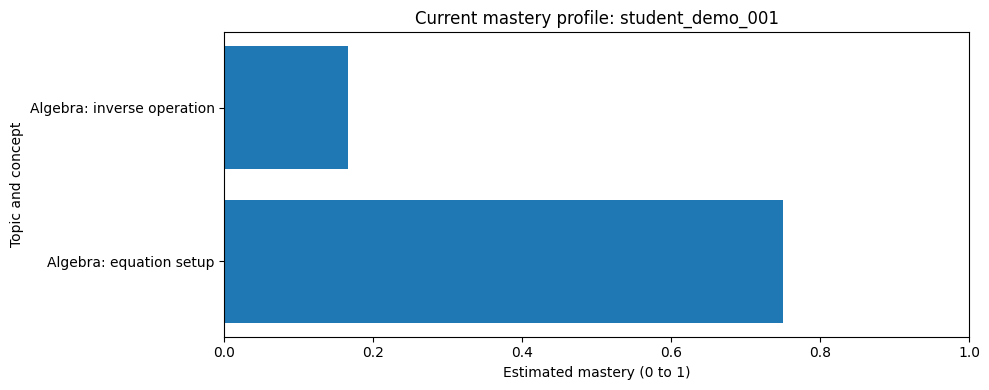

Recommended next problem: ALG-QUAD-001 - Solve x^2 - 5x + 6 = 0 by factoring.


,rank,problem_id,topic,difficulty,score,prompt
0,1,ALG-QUAD-001,Algebra,2,4.9,Solve x^2 - 5x + 6 = 0 by factoring.
1,2,ALG-LIN-001,Algebra,1,4.7,Solve 2x + 3 = 11. Show each algebraic transfo...
2,3,ARITH-001,Arithmetic,1,2.4,Compute 3/4 + 2/3. Show a common-denominator s...
3,4,PROB-001,Probability,2,2.4,Two fair coins are tossed. Find the probabilit...
4,5,CALC-DERIV-001,Calculus,2,1.4,Differentiate f(x) = x^3 - 4x + 7 with respect...


In [14]:

def plot_mastery(student_id: str, db_path: Path = DB_PATH) -> None:
    summary = weakness_summary(student_id, db_path)
    if summary.empty:
        print("No attempt history is available yet.")
        return
    labels = summary["topic"] + ": " + summary["concept"].str.replace("_", " ")
    values = summary["mastery"]
    plt.figure(figsize=(10, max(4, 0.55 * len(summary))))
    plt.barh(labels, values)
    plt.xlim(0, 1)
    plt.xlabel("Estimated mastery (0 to 1)")
    plt.ylabel("Topic and concept")
    plt.title(f"Current mastery profile: {student_id}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_mastery(sample_profile.student_id)
next_problem, ranking = recommend_next_problem(sample_profile)
print("Recommended next problem:", next_problem.problem_id, "-", next_problem.prompt)
ranking.head()


## 9. Reinforcement learning for feeback-style selection

In [15]:

FEEDBACK_STYLES = ["socratic", "concise_hint", "worked_example"]


class FeedbackBandit:
    def __init__(self, epsilon: float = 0.15):
        self.epsilon = epsilon
        self.counts: Dict[Tuple[str, str], int] = defaultdict(int)
        self.values: Dict[Tuple[str, str], float] = defaultdict(float)

    def choose(self, context_key: str, preferred_style: Optional[str] = None) -> str:
        if preferred_style in FEEDBACK_STYLES and sum(
            self.counts[(context_key, action)] for action in FEEDBACK_STYLES
        ) == 0:
            return str(preferred_style)
        if random.random() < self.epsilon:
            return random.choice(FEEDBACK_STYLES)
        return max(
            FEEDBACK_STYLES,
            key=lambda action: (self.values[(context_key, action)], -FEEDBACK_STYLES.index(action)),
        )

    def update(self, context_key: str, action: str, reward: float) -> None:
        key = (context_key, action)
        self.counts[key] += 1
        n = self.counts[key]
        old_value = self.values[key]
        self.values[key] = old_value + (reward - old_value) / n

    def table(self) -> pd.DataFrame:
        rows = []
        contexts = sorted({context for context, _ in self.counts.keys()} | set(ERROR_LABELS))
        for context in contexts:
            for action in FEEDBACK_STYLES:
                rows.append({
                    "context": context,
                    "action": action,
                    "count": self.counts[(context, action)],
                    "estimated_reward": round(self.values[(context, action)], 3),
                })
        return pd.DataFrame(rows)


FEEDBACK_BANDIT = FeedbackBandit(epsilon=0.15)


def create_feedback(evaluation: StepEvaluation, problem: MathProblem, style: str) -> str:
    concept_name = evaluation.concept.replace("_", " ")
    expected = evaluation.expected_step or "the next valid transformation"
    if evaluation.is_correct:
        return (
            f"Correct. Your step preserves the mathematics and demonstrates {concept_name}. "
            "Continue to the next transformation."
        )

    if style == "socratic":
        prompts = {
            "calculation_error": "Recalculate only the numerical part. Which arithmetic operation changed the value?",
            "sign_error": "What should happen to the sign when you move or simplify this term?",
            "algebra_transformation_error": "Did you apply the same legal operation to every required part of the expression or equation?",
            "concept_gap": f"Which rule governs {concept_name}, and what conditions must be true before using it?",
            "incomplete_step": "What mathematical statement would make this line complete?",
            "format_or_parse_error": "Can you rewrite this as one explicit expression or equation using an equals sign?",
        }
        return prompts.get(evaluation.error_type, "What is the next mathematically justified transformation?")

    if style == "worked_example":
        examples = {
            "calculation_error": "Parallel example: 2a + 3 = 11 becomes 2a = 8 after subtracting 3 from both sides.",
            "sign_error": "Parallel example: -(x - 2) expands to -x + 2, because the negative sign multiplies both terms.",
            "algebra_transformation_error": "Parallel example: from 3z = 12, divide both sides by 3 to obtain z = 4.",
            "concept_gap": f"Review a small example of {concept_name}, then apply the same rule to your current line.",
            "incomplete_step": "Parallel example: instead of writing '2x =', finish the statement as '2x = 8'.",
            "format_or_parse_error": "Use a format such as '2*x + 3 = 11' or '3*x**2 - 4'.",
        }
        return examples.get(evaluation.error_type, f"Compare your line with the expected structure: {expected}")

    # concise_hint
    hints = {
        "calculation_error": "Recheck the arithmetic before continuing.",
        "sign_error": "Audit every plus and minus sign.",
        "algebra_transformation_error": "Preserve equivalence by applying a valid operation consistently.",
        "concept_gap": f"Review the {concept_name} rule.",
        "incomplete_step": "Complete the expression or equation.",
        "format_or_parse_error": "Rewrite using explicit mathematical notation.",
    }
    return hints.get(evaluation.error_type, evaluation.explanation)


def record_feedback_reward(
    student_id: str,
    context_key: str,
    style: str,
    reward: float,
    db_path: Path = DB_PATH,
) -> None:
    FEEDBACK_BANDIT.update(context_key, style, reward)
    with get_connection(db_path) as conn:
        conn.execute(
            """
            INSERT INTO feedback_events (student_id, context_key, feedback_style, reward, created_at)
            VALUES (?, ?, ?, ?, ?)
            """,
            (student_id, context_key, style, float(reward), datetime.now(timezone.utc).isoformat()),
        )


# Simulate feedback interactions to demonstrate learning.
for _ in range(30):
    record_feedback_reward("student_demo_001", "calculation_error", "socratic", random.choice([0, 1, 1]))
for _ in range(20):
    record_feedback_reward("student_demo_001", "calculation_error", "worked_example", random.choice([-1, 0, 1]))
for _ in range(15):
    record_feedback_reward("student_demo_001", "calculation_error", "concise_hint", random.choice([-1, 0]))

FEEDBACK_BANDIT.table().query("context == 'calculation_error'")


,context,action,count,estimated_reward
3,calculation_error,socratic,30,0.533
4,calculation_error,concise_hint,15,-0.600
5,calculation_error,worked_example,20,-0.300


## 10. End-to-end mentor report

This funciton combines the checker, scoring, database, weakness model, adaptive recoomendation, and RL-selected feedback style.

In [16]:

def run_mentor_attempt(
    profile: StudentProfile,
    problem_id: str,
    student_steps: Sequence[str],
    save: bool = True,
) -> Dict[str, Any]:
    if problem_id not in PROBLEMS_BY_ID:
        raise KeyError(f"Unknown problem_id: {problem_id}")
    problem = PROBLEMS_BY_ID[problem_id]
    evaluations = evaluate_solution_steps(problem, student_steps)
    scores = solution_score(evaluations, problem)

    attempt_id = None
    if save:
        attempt_id = record_attempt(profile, problem, evaluations)

    feedback_rows = []
    for evaluation in evaluations:
        style = FEEDBACK_BANDIT.choose(
            evaluation.error_type,
            preferred_style=profile.preferred_feedback,
        )
        feedback_rows.append({
            "step": evaluation.student_step_index,
            "style": style,
            "feedback": create_feedback(evaluation, problem, style),
        })

    attempted_ids = []
    history = load_student_history(profile.student_id)
    if not history.empty:
        attempted_ids = history["problem_id"].unique().tolist()
    recommendation, ranking = recommend_next_problem(
        profile,
        attempted_problem_ids=attempted_ids,
    )

    return {
        "attempt_id": attempt_id,
        "profile": asdict(profile),
        "problem": asdict(problem),
        "scores": scores,
        "evaluations": [asdict(e) for e in evaluations],
        "feedback": feedback_rows,
        "weakness_summary": weakness_summary(profile.student_id).to_dict(orient="records"),
        "recommended_problem": asdict(recommendation),
        "recommendation_ranking": ranking.to_dict(orient="records"),
    }


def report_to_markdown(report: Dict[str, Any]) -> str:
    problem = report["problem"]
    scores = report["scores"]
    lines = [
        f"# Math Mentor Report",
        f"",
        f"**Problem:** {problem['problem_id']} - {problem['prompt']}",
        f"",
        f"**Overall score:** {scores['overall_score']} / 100  ",
        f"**Submitted-step accuracy:** {100*scores['step_accuracy']:.1f}%  ",
        f"**Expected-path coverage:** {100*scores['coverage']:.1f}%",
        f"",
        "## Step analysis",
    ]
    feedback_by_step = {item["step"]: item for item in report["feedback"]}
    for evaluation in report["evaluations"]:
        marker = "Correct" if evaluation["is_correct"] else "Needs revision"
        lines.extend([
            f"### Step {evaluation['student_step_index']}: {marker}",
            f"- Submitted: `{evaluation['student_step']}`",
            f"- Expected target: `{evaluation['expected_step']}`",
            f"- Category: `{evaluation['error_type']}`",
            f"- Concept: `{evaluation['concept']}`",
            f"- Diagnosis: {evaluation['explanation']}",
            f"- Mentor response ({feedback_by_step[evaluation['student_step_index']]['style']}): "
            f"{feedback_by_step[evaluation['student_step_index']]['feedback']}",
            "",
        ])

    recommendation = report["recommended_problem"]
    lines.extend([
        "## Recommended next problem",
        f"**{recommendation['problem_id']}** ({recommendation['topic']}, difficulty {recommendation['difficulty']}): "
        f"{recommendation['prompt']}",
    ])
    return "\n".join(lines)


end_to_end_report = run_mentor_attempt(
    sample_profile,
    "PROB-001",
    [
        "P_none = (1/2)**2",
        "P_at_least_one = 1 - P_none",
        "P_at_least_one = 1/4",  # intentional error
    ],
)
display(Markdown(report_to_markdown(end_to_end_report)))


# Math Mentor Report

**Problem:** PROB-001 - Two fair coins are tossed. Find the probability of at least one head using the complement rule.

**Overall score:** 66.7 / 100  
**Submitted-step accuracy:** 66.7%  
**Expected-path coverage:** 66.7%

## Step analysis
### Step 1: Correct
- Submitted: `P_none = (1/2)**2`
- Expected target: `P_none = (1/2)**2`
- Category: `correct`
- Concept: `independence`
- Diagnosis: This step is mathematically equivalent to the expected step.
- Mentor response (socratic): Correct. Your step preserves the mathematics and demonstrates independence. Continue to the next transformation.

### Step 2: Correct
- Submitted: `P_at_least_one = 1 - P_none`
- Expected target: `P_at_least_one = 1 - P_none`
- Category: `correct`
- Concept: `complement_rule`
- Diagnosis: This step is mathematically equivalent to the expected step.
- Mentor response (socratic): Correct. Your step preserves the mathematics and demonstrates complement rule. Continue to the next transformation.

### Step 3: Needs revision
- Submitted: `P_at_least_one = 1/4`
- Expected target: `P_at_least_one = 3/4`
- Category: `calculation_error`
- Concept: `simplification`
- Diagnosis: The operation pattern is plausible, but one or more numerical calculations do not match.
- Mentor response (socratic): Recalculate only the numerical part. Which arithmetic operation changed the value?

## Recommended next problem
**PROB-001** (Probability, difficulty 2): Two fair coins are tossed. Find the probability of at least one head using the complement rule.

## 11. Export a student's report and learning data

The export includes a Markdown report, JSON result object, and CSV tables. In production, exports should follow data-minimization rules and should never expose another student's records.

In [17]:

def export_report(report: Dict[str, Any], export_dir: Path = EXPORT_DIR) -> Dict[str, Path]:
    export_dir.mkdir(parents=True, exist_ok=True)
    attempt_id = report.get("attempt_id") or "unsaved"
    prefix = export_dir / f"math_mentor_attempt_{attempt_id}"

    markdown_path = prefix.with_suffix(".md")
    json_path = prefix.with_suffix(".json")
    steps_path = export_dir / f"math_mentor_attempt_{attempt_id}_steps.csv"
    weakness_path = export_dir / f"math_mentor_attempt_{attempt_id}_weaknesses.csv"

    markdown_path.write_text(report_to_markdown(report), encoding="utf-8")
    json_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")
    pd.DataFrame(report["evaluations"]).to_csv(steps_path, index=False)
    pd.DataFrame(report["weakness_summary"]).to_csv(weakness_path, index=False)

    return {
        "markdown": markdown_path,
        "json": json_path,
        "steps_csv": steps_path,
        "weakness_csv": weakness_path,
    }


exported_files = export_report(end_to_end_report)
for label, path in exported_files.items():
    print(f"{label}: {path}")


markdown: /content/ai_math_mentor_exports/math_mentor_attempt_3.md
json: /content/ai_math_mentor_exports/math_mentor_attempt_3.json
steps_csv: /content/ai_math_mentor_exports/math_mentor_attempt_3_steps.csv
weakness_csv: /content/ai_math_mentor_exports/math_mentor_attempt_3_weaknesses.csv


## 12. Optional Gradio browser interface


In [18]:

def build_gradio_demo():
    import gradio as gr

    problem_choices = [
        (f"{p.problem_id} | {p.topic} | difficulty {p.difficulty}", p.problem_id)
        for p in PROBLEM_BANK
    ]

    def ui_analyze(display_name, grade_band, algebra_level, calculus_level, probability_level,
                   differential_equations_level, preferred_feedback, problem_id, steps_text):
        profile = StudentProfile(
            student_id="gradio_" + re.sub(r"[^a-zA-Z0-9]+", "_", (display_name or "student")).strip("_").lower(),
            display_name=display_name or "Student",
            grade_band=grade_band,
            current_levels={
                "Algebra": algebra_level,
                "Calculus": calculus_level,
                "Probability": probability_level,
                "Differential Equations": differential_equations_level,
            },
            preferred_feedback=preferred_feedback,
        )
        steps = [line.strip() for line in (steps_text or "").splitlines() if line.strip()]
        if not steps:
            return "Please enter at least one solution step, with one step per line."
        report = run_mentor_attempt(profile, problem_id, steps, save=True)
        return report_to_markdown(report)

    with gr.Blocks(title="AI Math Mentor") as demo:
        gr.Markdown("# AI Math Mentor Prototype")
        gr.Markdown("Enter one mathematical step per line. This prototype uses symbolic checking plus ML-based error diagnosis.")
        with gr.Row():
            with gr.Column():
                display_name = gr.Textbox(label="Display name", value="Demo Student")
                grade_band = gr.Dropdown(
                    ["Grades 5-7", "Grades 7-10", "Grades 9-12", "College / AP", "College"],
                    value="Grades 9-12",
                    label="Grade band",
                )
                preferred_feedback = gr.Radio(
                    FEEDBACK_STYLES,
                    value="socratic",
                    label="Preferred feedback style",
                )
            with gr.Column():
                algebra_level = gr.Dropdown(list(LEVEL_TO_DIFFICULTY), value="intermediate", label="Algebra level")
                calculus_level = gr.Dropdown(list(LEVEL_TO_DIFFICULTY), value="entry", label="Calculus level")
                probability_level = gr.Dropdown(list(LEVEL_TO_DIFFICULTY), value="intermediate", label="Probability level")
                differential_equations_level = gr.Dropdown(
                    list(LEVEL_TO_DIFFICULTY), value="entry", label="Differential equations level"
                )
        problem_id = gr.Dropdown(problem_choices, value="ALG-LIN-001", label="Problem")
        steps_text = gr.Textbox(
            label="Solution steps (one per line)",
            lines=8,
            value="2*x + 3 = 11\n2*x = 8\nx = 4",
        )
        analyze_button = gr.Button("Analyze solution")
        report_output = gr.Markdown()
        analyze_button.click(
            ui_analyze,
            inputs=[
                display_name,
                grade_band,
                algebra_level,
                calculus_level,
                probability_level,
                differential_equations_level,
                preferred_feedback,
                problem_id,
                steps_text,
            ],
            outputs=report_output,
        )
    return demo


if RUN_GRADIO:
    gradio_demo = build_gradio_demo()
    gradio_demo.launch(share=False, debug=False)
else:
    print("Gradio launch skipped. Set RUN_GRADIO = True and rerun this cell to start the interface.")


Gradio launch skipped. Set RUN_GRADIO = True and rerun this cell to start the interface.
